In [1]:
import networkx as nx
import random
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

In [2]:
def find_max_independent_set(graph):
    best_independent_set = set()  #stores the largest independent set found
    vertices = list(graph.nodes())  #list of vertices in the graph
    #for recording the time
    start_time = time.time ()

    for initial_vertex in vertices:
        independent_set = set()  #independent set for the current iteration
        independent_set.add(initial_vertex)

        #add neighbors of the initial vertex to the independent set if feasible
        neighbors = list(graph.neighbors(initial_vertex))
        for neighbor in neighbors:
            if all(not graph.has_edge(neighbor, node) for node in independent_set):
                independent_set.add(neighbor)

        #update adjacency matrix by removing edges adjacent to nodes in the independent set and their neighbors
        temp_graph = graph.copy()
        nodes_to_remove = set(independent_set)
        for node in independent_set:
            if node in temp_graph:  
                nodes_to_remove.update(temp_graph.neighbors(node))
        temp_graph.remove_nodes_from(nodes_to_remove)

        #repeat the improvement process
        while temp_graph.number_of_edges() > 0:
            #find the vertex with the maximum degree
            max_degree_vertex = max(temp_graph.degree, key=lambda x: x[1])[0]

            #add neighbors of the maximum degree vertex if feasible
            neighbors = list(temp_graph.neighbors(max_degree_vertex))
            for neighbor in neighbors:
                if all(not graph.has_edge(neighbor, node) for node in independent_set):
                    independent_set.add(neighbor)

            #update the adjacency matrix
            nodes_to_remove = set(independent_set)
            for node in independent_set:
                if node in temp_graph:  
                    nodes_to_remove.update(temp_graph.neighbors(node))
            temp_graph.remove_nodes_from(nodes_to_remove)

        #try to add remaining vertices to the independent set
        for vertex in graph.nodes():
            if vertex not in independent_set and all(
                neighbor not in independent_set for neighbor in graph.neighbors(vertex)
            ):
                independent_set.add(vertex)

        #try shifting vertices to create feasible additions
        for vertex in vertices:
            if vertex not in independent_set:
                neighbors = list(graph.neighbors(vertex))
                for neighbor in neighbors:
                    if neighbor in independent_set and len(neighbors) == 1:
                        independent_set.remove(neighbor)
                        independent_set.add(vertex)
                        break

        #update the best independent set if the current one is larger
        if len(independent_set) > len(best_independent_set):
            best_independent_set = independent_set

    #calculating the total time taken by the algorithm
    end_time = time.time ()
    total_time = end_time - start_time

    return best_independent_set,total_time

def generate_random_graph(num_vertices, edge_probability):
    G = nx.Graph()
    G.add_nodes_from(range(num_vertices))
    
    for i in range(num_vertices):
        for j in range(i + 1, num_vertices):
            if random.random() < edge_probability:
                G.add_edge(i, j)
    
    return G

In [6]:
def performance_test(num_runs):
    graph_sizes = [10, 20, 40, 80, 160, 320]  
    edge_probability = 0.2  
    results = []

    for size in graph_sizes:
        runtimes = []

        #generate a random graph and measure runtime num_runs times
        for _ in range(num_runs):
            graph = generate_random_graph(size, edge_probability)
            _, runtime = find_max_independent_set(graph)
            runtimes.append(runtime)

        #compute mean and standard deviation
        mean_runtime = np.mean(runtimes)
        std_dev = np.std(runtimes, ddof=1)
        std_error = std_dev / np.sqrt(num_runs)

        if num_runs == 50:
            t_value_90 = 1.680  #T-value for 90% confidence level with 50 degrees of freedom between 1.671-1.684
            t_value_95 = 2.010  #T-value for 95% confidence level with 50 degrees of freedom between 2.000-2.021
        elif num_runs == 100:
            t_value_90 = 1.660  #T-value for 90% confidence level with 100 degrees of freedom
            t_value_95 = 1.984  #T-value for 95% confidence level with 100 degrees of freedom

        confidence_interval_90 = (
            mean_runtime - t_value_90 * std_error,
            mean_runtime + t_value_90 * std_error
        )
        confidence_interval_95 = (
            mean_runtime - t_value_95 * std_error,
            mean_runtime + t_value_95 * std_error
        )

        results.append({
            'size': size,
            'mean_runtime': mean_runtime,
            'std_dev': std_dev,
            'confidence_interval_90': confidence_interval_90,
            'confidence_interval_95': confidence_interval_95
        })

    #print results
    for result in results:
        print(f"Graph Size: {result['size']}")
        print(f"  Mean Runtime: {result['mean_runtime']:.4f}")
        print(f"  Standard Deviation: {result['std_dev']:.4f}")
        print(f"  90% Confidence Interval: {result['confidence_interval_90']}")
        print(f"  95% Confidence Interval: {result['confidence_interval_95']}")
        print()

    return results

Graph Size: 10
  Mean Runtime: 0.0009
  Standard Deviation: 0.0005
  90% Confidence Interval: (0.0007696199664165031, 0.000995240186781739)
  95% Confidence Interval: (0.0007474608376306318, 0.0010173993155676104)

Graph Size: 20
  Mean Runtime: 0.0041
  Standard Deviation: 0.0008
  90% Confidence Interval: (0.0039054602298290264, 0.004273861059233473)
  95% Confidence Interval: (0.0038692780055125183, 0.004310043283549981)

Graph Size: 40
  Mean Runtime: 0.0236
  Standard Deviation: 0.0032
  90% Confidence Interval: (0.022823222733729866, 0.024327103041416616)
  95% Confidence Interval: (0.02267552020351063, 0.024474805571635852)

Graph Size: 80
  Mean Runtime: 0.1605
  Standard Deviation: 0.0151
  90% Confidence Interval: (0.15687260215898102, 0.16403745109419282)
  95% Confidence Interval: (0.15616891163855845, 0.1647411416146154)

Graph Size: 160
  Mean Runtime: 1.1672
  Standard Deviation: 0.0523
  90% Confidence Interval: (1.1548239690283675, 1.179663020946608)
  95% Confidence I

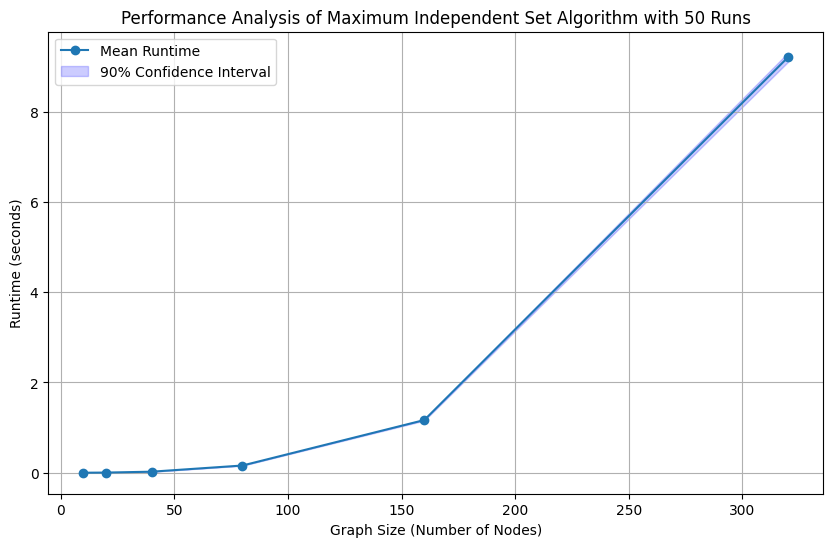

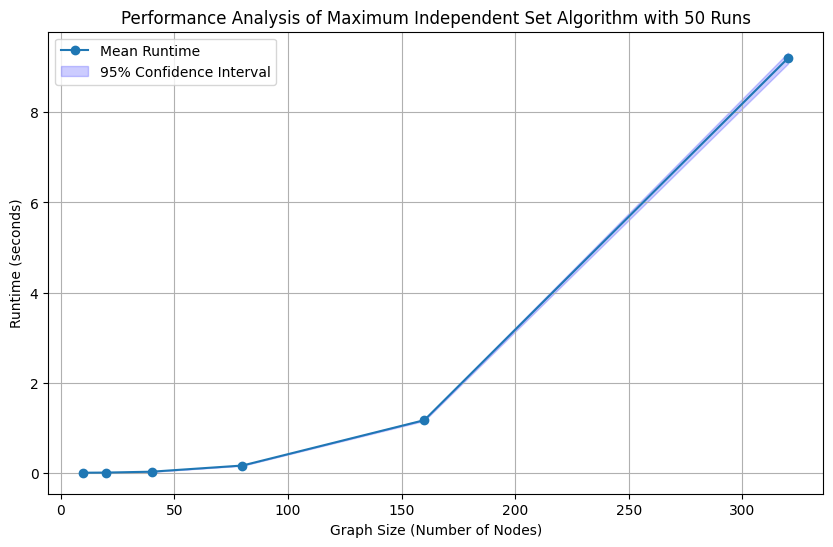

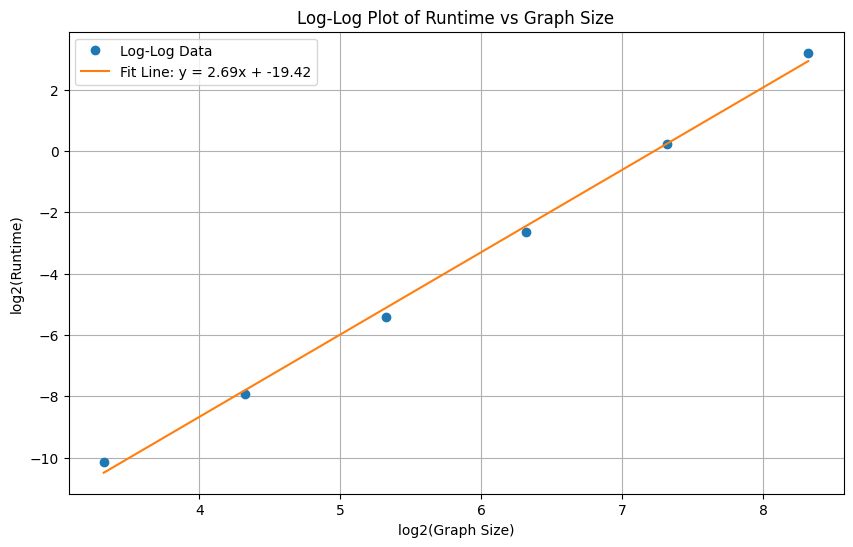

In [7]:
results = performance_test(50)

sizes = [res['size'] for res in results]
mean_runtimes = [res['mean_runtime'] for res in results]
conf_intervals = [res['confidence_interval_90'] for res in results]

#plot runtime vs graph size
plt.figure(figsize=(10, 6))
plt.plot(sizes, mean_runtimes, marker='o', label='Mean Runtime')
plt.fill_between(sizes,
                 [ci[0] for ci in conf_intervals],
                 [ci[1] for ci in conf_intervals],
                 color='b', alpha=0.2, label='90% Confidence Interval')
plt.xlabel('Graph Size (Number of Nodes)')
plt.ylabel('Runtime (seconds)')
plt.title('Performance Analysis of Maximum Independent Set Algorithm with 50 Runs')
plt.legend()
plt.grid()
plt.show()

sizes = [res['size'] for res in results]
mean_runtimes = [res['mean_runtime'] for res in results]
conf_intervals = [res['confidence_interval_95'] for res in results]

#plot runtime vs graph size
plt.figure(figsize=(10, 6))
plt.plot(sizes, mean_runtimes, marker='o', label='Mean Runtime')
plt.fill_between(sizes,
                 [ci[0] for ci in conf_intervals],
                 [ci[1] for ci in conf_intervals],
                 color='b', alpha=0.2, label='95% Confidence Interval')
plt.xlabel('Graph Size (Number of Nodes)')
plt.ylabel('Runtime (seconds)')
plt.title('Performance Analysis of Maximum Independent Set Algorithm with 50 Runs')
plt.legend()
plt.grid()
plt.show()

#log-log plot
log_sizes = np.log2(sizes)
log_runtimes = np.log2(mean_runtimes)

#fit a line to the log-log data
coeffs = np.polyfit(log_sizes, log_runtimes, 1)
fit_line = np.polyval(coeffs, log_sizes)

plt.figure(figsize=(10, 6))
plt.plot(log_sizes, log_runtimes, 'o', label='Log-Log Data')
plt.plot(log_sizes, fit_line, '-', label=f'Fit Line: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}')
plt.xlabel('log2(Graph Size)')
plt.ylabel('log2(Runtime)')
plt.title('Log-Log Plot of Runtime vs Graph Size')
plt.legend()
plt.grid()
plt.show()


Graph Size: 10
  Mean Runtime: 0.0009
  Standard Deviation: 0.0005
  90% Confidence Interval: (0.000839003179943574, 0.0009884275451540823)
  95% Confidence Interval: (0.0008244208021338737, 0.0010030099229637827)

Graph Size: 20
  Mean Runtime: 0.0048
  Standard Deviation: 0.0048
  90% Confidence Interval: (0.004038989698510653, 0.005619323099035734)
  95% Confidence Interval: (0.003884764390748567, 0.00577354840679782)

Graph Size: 40
  Mean Runtime: 0.0227
  Standard Deviation: 0.0031
  90% Confidence Interval: (0.02223376922122828, 0.023248484807092032)
  95% Confidence Interval: (0.022134742760439165, 0.023347511267881146)

Graph Size: 80
  Mean Runtime: 0.1592
  Standard Deviation: 0.0250
  90% Confidence Interval: (0.15503962240471952, 0.16334352769598848)
  95% Confidence Interval: (0.15422924128593304, 0.16415390881477496)

Graph Size: 160
  Mean Runtime: 1.3236
  Standard Deviation: 0.2404
  90% Confidence Interval: (1.2836648223089129, 1.363476634295091)
  95% Confidence Int

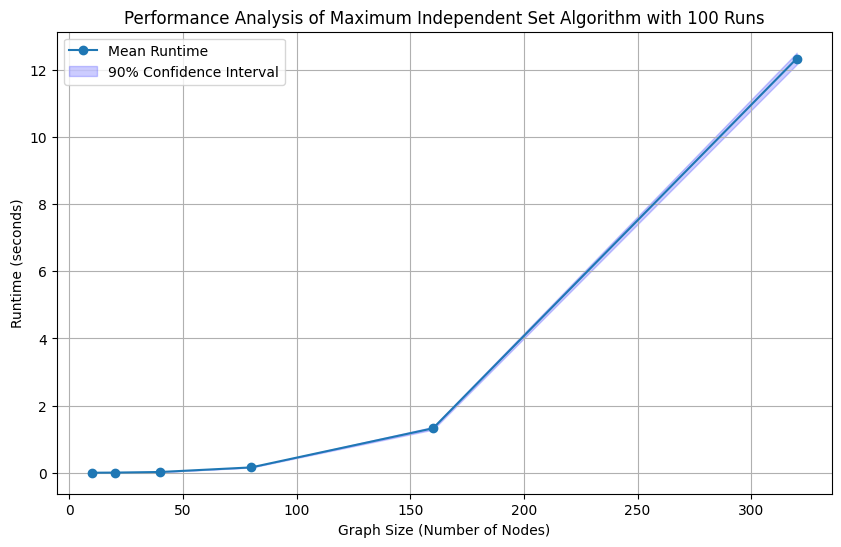

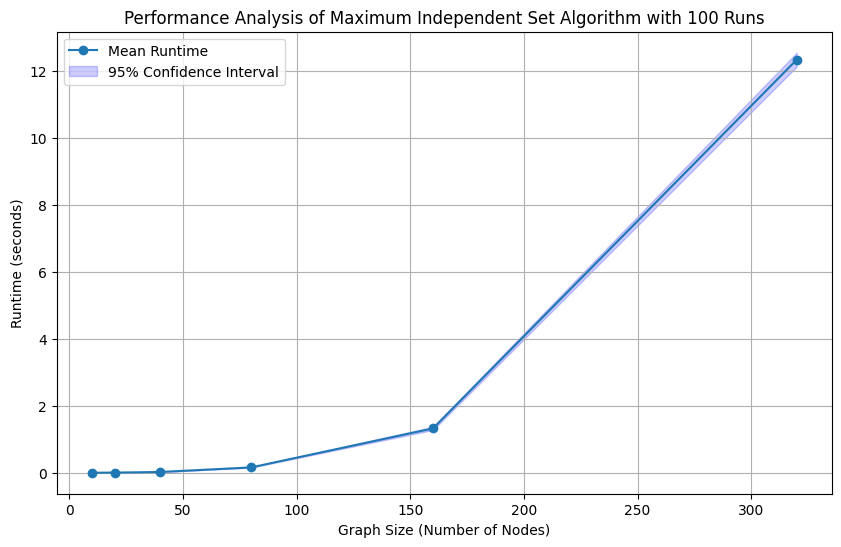

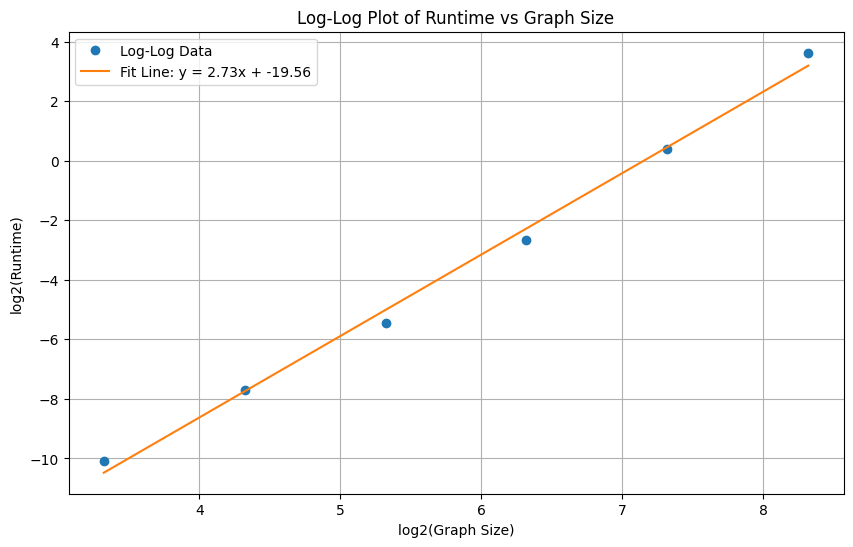

In [8]:
results = performance_test(100)

sizes = [res['size'] for res in results]
mean_runtimes = [res['mean_runtime'] for res in results]
conf_intervals = [res['confidence_interval_90'] for res in results]

#plot runtime vs graph size
plt.figure(figsize=(10, 6))
plt.plot(sizes, mean_runtimes, marker='o', label='Mean Runtime')
plt.fill_between(sizes,
                 [ci[0] for ci in conf_intervals],
                 [ci[1] for ci in conf_intervals],
                 color='b', alpha=0.2, label='90% Confidence Interval')
plt.xlabel('Graph Size (Number of Nodes)')
plt.ylabel('Runtime (seconds)')
plt.title('Performance Analysis of Maximum Independent Set Algorithm with 100 Runs')
plt.legend()
plt.grid()
plt.show()

sizes = [res['size'] for res in results]
mean_runtimes = [res['mean_runtime'] for res in results]
conf_intervals = [res['confidence_interval_95'] for res in results]

#plot runtime vs graph size
plt.figure(figsize=(10, 6))
plt.plot(sizes, mean_runtimes, marker='o', label='Mean Runtime')
plt.fill_between(sizes,
                 [ci[0] for ci in conf_intervals],
                 [ci[1] for ci in conf_intervals],
                 color='b', alpha=0.2, label='95% Confidence Interval')
plt.xlabel('Graph Size (Number of Nodes)')
plt.ylabel('Runtime (seconds)')
plt.title('Performance Analysis of Maximum Independent Set Algorithm with 100 Runs')
plt.legend()
plt.grid()
plt.show()

#log-log plot
log_sizes = np.log2(sizes)
log_runtimes = np.log2(mean_runtimes)

#fit a line to the log-log data
coeffs = np.polyfit(log_sizes, log_runtimes, 1)
fit_line = np.polyval(coeffs, log_sizes)

plt.figure(figsize=(10, 6))
plt.plot(log_sizes, log_runtimes, 'o', label='Log-Log Data')
plt.plot(log_sizes, fit_line, '-', label=f'Fit Line: y = {coeffs[0]:.2f}x + {coeffs[1]:.2f}')
plt.xlabel('log2(Graph Size)')
plt.ylabel('log2(Runtime)')
plt.title('Log-Log Plot of Runtime vs Graph Size')
plt.legend()
plt.grid()
plt.show()